# Problem statment

db by: imakash3011/customer-analysis-eda-report-clustering <br>
I analyze customer purchasing behavior and see if having children, customers's age or being in a relationship affects the type of purchases or sales channel

In [34]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style= "whitegrid")

# Attributes <br>

## People <br>

- ID: Customer's unique identifier
- Year_Birth: Customer's birth year
- Education: Customer's education level
- Marital_Status: Customer's marital status
- Income: Customer's yearly household income
- Kidhome: Number of children in customer's household
- Teenhome: Number of teenagers in customer's household
- Dt_Customer: Date of customer's enrollment with the company
- Recency: Number of days since customer's last purchase
- Complain: 1 if customer complained in the last 2 years, 0 otherwise

## Products

- MntWines: Amount spent on wine in last 2 years
- MntFruits: Amount spent on fruits in last 2 years
- MntMeatProducts: Amount spent on meat in last 2 years
- MntFishProducts: Amount spent on fish in last 2 years
- MntSweetProducts: Amount spent on sweets in last 2 years
- MntGoldProds: Amount spent on gold in last 2 years

## Promotion

- NumDealsPurchases: Number of purchases made with a discount
- AcceptedCmp1: 1 if customer accepted the offer in the 1st campaign, 0 otherwise
- AcceptedCmp2: 1 if customer accepted the offer in the 2nd campaign, 0 otherwise
- AcceptedCmp3: 1 if customer accepted the offer in the 3rd campaign, 0 otherwise
- AcceptedCmp4: 1 if customer accepted the offer in the 4th campaign, 0 otherwise
- AcceptedCmp5: 1 if customer accepted the offer in the 5th campaign, 0 otherwise
- Response: 1 if customer accepted the offer in the last campaign, 0 otherwise

## Place

- NumWebPurchases: Number of purchases made through the company’s web site
- NumCatalogPurchases: Number of purchases made using a catalogue
- NumStorePurchases: Number of purchases made directly in stores
- NumWebVisitsMonth: Number of visits to company’s web site in the last month

In [35]:
marketing_data= pd.read_csv("data_raw/marketing_campaign.csv", sep= "\t")
marketing_data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [36]:
marketing_data.shape

(2240, 29)

In [37]:
marketing_data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [38]:
marketing_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [39]:
marketing_data.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [40]:
marketing_data.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [41]:
#find the unique element present in each column
marketing_data.nunique()

ID                     2240
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             663
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         558
MntFishProducts         182
MntSweetProducts        177
MntGoldProds            213
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

In [42]:
#in Z_costcontact ad Z_revenue we have only 1 value, so we can drop them, because they don't contribute in the analysis.
marketing_data= marketing_data.drop(["Z_CostContact", "Z_Revenue"], axis= 1)

In [43]:
#we substitues the nan values of the income column with the mean of the income
marketing_data["Income"] = marketing_data["Income"].fillna(marketing_data["Income"].mean())

In [44]:
# check if there are no more nan values
marketing_data.isna().any()

ID                     False
Year_Birth             False
Education              False
Marital_Status         False
Income                 False
Kidhome                False
Teenhome               False
Dt_Customer            False
Recency                False
MntWines               False
MntFruits              False
MntMeatProducts        False
MntFishProducts        False
MntSweetProducts       False
MntGoldProds           False
NumDealsPurchases      False
NumWebPurchases        False
NumCatalogPurchases    False
NumStorePurchases      False
NumWebVisitsMonth      False
AcceptedCmp3           False
AcceptedCmp4           False
AcceptedCmp5           False
AcceptedCmp1           False
AcceptedCmp2           False
Complain               False
Response               False
dtype: bool

In [45]:
# the marital_status have a lot of values, check what type of values are in the column
marketing_data["Marital_Status"]. value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [46]:
#grouping together the married/together values in "relationship" and single/divorced/widow/alone/YOLO/absurd in "single"
marketing_data["Marital_Status"] = marketing_data["Marital_Status"].replace(["Married", "Together"], "relationship")
marketing_data["Marital_Status"] = marketing_data["Marital_Status"].replace(["Single", "Divorced", "Absurd","Widow", "Alone", "YOLO"], "single")

In [47]:
#check the new value_counts:
marketing_data["Marital_Status"].value_counts()

Marital_Status
relationship    1444
single           796
Name: count, dtype: int64

In [48]:
#check the value counts of the education column:
marketing_data["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [49]:
#aggregate the education status , Graduation, "PHD", "Master" and 2n Cycle to one col: 
marketing_data["Education"] = marketing_data["Education"].replace(["PhD", "Master", "2n Cycle", "Graduation"], "higher_education")

In [50]:
#check the new value counts.
marketing_data["Education"].value_counts()

Education
higher_education    2186
Basic                 54
Name: count, dtype: int64

In [51]:
#to semplify the dataset i will aggregate the  acctepted offer by different campaigns in one, keep keeping separate the discount sales.
def accepted_campaign(row):
    if row["AcceptedCmp1"] == 1:
        return "1st_campaign"
    elif row["AcceptedCmp2"] == 1:
        return "2nd_campaign"
    elif row["AcceptedCmp3"] == 1:
        return "3rd_campaign"
    elif row["AcceptedCmp4"] == 1:
        return "4th_campaign"
    elif row["AcceptedCmp5"] == 1:
        return "5th_campaign"
    elif row["Response"] == 1:
        return "last_campaign"
    else:
        return "no campaign"



marketing_data["Accepted_campaign"] = marketing_data.apply(accepted_campaign, axis=1)

In [52]:
# control if the values of the new column are correct
marketing_data["Accepted_campaign"].value_counts()

Accepted_campaign
no campaign      1631
last_campaign     146
1st_campaign      144
3rd_campaign      135
4th_campaign      108
5th_campaign       59
2nd_campaign       17
Name: count, dtype: int64

In [53]:
#Clean che AcceptedCmd cols from the db
marketing_data.drop(["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"], axis=1, inplace= True)

In [54]:
#check the new db:
marketing_data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Accepted_campaign
0,5524,1957,higher_education,single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,last_campaign
1,2174,1954,higher_education,single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,no campaign
2,4141,1965,higher_education,relationship,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,no campaign
3,6182,1984,higher_education,relationship,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,no campaign
4,5324,1981,higher_education,relationship,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,no campaign


In [55]:
#create a col "Age" to sobtstitute the Year_birth col:
marketing_data["Age"]= 2026 - marketing_data["Year_Birth"]

In [56]:
#check if there are absurd ages in the dataset (>= 100):
marketing_data[marketing_data["Age"] >= 100]["Age"].value_counts()

Age
126    1
133    1
127    1
Name: count, dtype: int64

In [57]:
#eliminate the Age values over 100:
marketing_data= marketing_data[marketing_data["Age"] < 100]

In [58]:
#drop the Year_Birth col:
marketing_data.drop(["Year_Birth"], axis=1, inplace= True)

In [59]:
#convert the Dt_customer to datetime:
marketing_data['Dt_Customer'] = pd.to_datetime(marketing_data['Dt_Customer'], dayfirst=True)


In [60]:
# drop the id col, it's not usefull for the analysis:
marketing_data.drop("ID", axis=1, inplace= True)

In [61]:
marketing_data.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Accepted_campaign,Age
0,higher_education,single,58138.0,0,0,2012-09-04,58,635,88,546,...,88,88,3,8,10,4,7,0,last_campaign,69
1,higher_education,single,46344.0,1,1,2014-03-08,38,11,1,6,...,1,6,2,1,1,2,5,0,no campaign,72
2,higher_education,relationship,71613.0,0,0,2013-08-21,26,426,49,127,...,21,42,1,8,2,10,4,0,no campaign,61
3,higher_education,relationship,26646.0,1,0,2014-02-10,26,11,4,20,...,3,5,2,2,0,4,6,0,no campaign,42
4,higher_education,relationship,58293.0,1,0,2014-01-19,94,173,43,118,...,27,15,5,5,3,6,5,0,no campaign,45


In [62]:
#Since I want to analyze whether purchasing behavior depends on having children. I create a function to define if the client have child, teen, both or none:
def classify_child(row):
    if row["Kidhome"] == 0 and row["Teenhome"] == 0:
        return "no_child"
    elif row["Kidhome"] == 1 and row["Teenhome"] == 0:
        return "only_kid"
    elif row["Kidhome"] == 0 and row["Teenhome"] == 1:
        return "only_teen"
    else:
        return "kid_and_teen"

marketing_data["Child"] = marketing_data.apply(classify_child,axis=1)

In [63]:
#control if the cols are corretly generated:
marketing_data.head(3)

,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Accepted_campaign,Age,Child
0,higher_education,single,58138.0,0,0,2012-09-04,58,635,88,546,...,88,3,8,10,4,7,0,last_campaign,69,no_child
1,higher_education,single,46344.0,1,1,2014-03-08,38,11,1,6,...,6,2,1,1,2,5,0,no campaign,72,kid_and_teen
2,higher_education,relationship,71613.0,0,0,2013-08-21,26,426,49,127,...,42,1,8,2,10,4,0,no campaign,61,no_child


In [64]:
#control if the values of the new cols are correct:
marketing_data["Child"].value_counts()

Child
no_child        637
only_teen       624
only_kid        502
kid_and_teen    474
Name: count, dtype: int64

In [65]:
#drop the 2 cols kidhome and teenhome:
marketing_data.drop(["Kidhome", "Teenhome"], axis= 1, inplace= True)

In [66]:
"""crea 2 new cols:
1- total spent
2- total purchased
I will not use for the current analysis, but they could containe usefull information"""

marketing_data["total_spent"]= marketing_data[["MntWines","MntFruits","MntMeatProducts", "MntFishProducts","MntSweetProducts","MntGoldProds"]].sum(axis=1)
marketing_data["total_purchased"] = marketing_data[["NumWebPurchases","NumCatalogPurchases","NumStorePurchases"]].sum(axis=1)

In [67]:
#control the new col of the dataset:
marketing_data.columns

Index(['Education', 'Marital_Status', 'Income', 'Dt_Customer', 'Recency',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Accepted_campaign', 'Age', 'Child',
       'total_spent', 'total_purchased'],
      dtype='str')

In [68]:
#Reorder the columns for more clarity:
marketing_data = marketing_data[[
    # user's info
    'Age', 'Education', 'Marital_Status', 'Income', 'Child', 'Dt_Customer', 'Recency',
    
    # Type of purchased + total
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'total_spent',
    
    # Sales channel + total
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases', 'NumWebVisitsMonth', 'total_purchased',
    
    # Campaign result and Compain
    'Accepted_campaign', 'Complain'
]]

In [69]:
marketing_data.head()

,Age,Education,Marital_Status,Income,Child,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,MntGoldProds,total_spent,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,total_purchased,Accepted_campaign,Complain
0,69,higher_education,single,58138.0,no_child,2012-09-04,58,635,88,546,...,88,1617,8,10,4,3,7,22,last_campaign,0
1,72,higher_education,single,46344.0,kid_and_teen,2014-03-08,38,11,1,6,...,6,27,1,1,2,2,5,4,no campaign,0
2,61,higher_education,relationship,71613.0,no_child,2013-08-21,26,426,49,127,...,42,776,8,2,10,1,4,20,no campaign,0
3,42,higher_education,relationship,26646.0,only_kid,2014-02-10,26,11,4,20,...,5,53,2,0,4,2,6,6,no campaign,0
4,45,higher_education,relationship,58293.0,only_kid,2014-01-19,94,173,43,118,...,15,422,5,3,6,5,5,14,no campaign,0


Now that i clean the data and obtaine the col that i need to analyze the Dataset, i save it. <br>
I will see if the the age, the relationship, having child and the type of child affects the type of purchased or sales channel

In [70]:
#save the dataset in data_clean folder, if the fold doesn't exist, i create it.
data_clean = "data_clean/marketing_data_clean.csv"
Path("data_clean").mkdir(parents=True, exist_ok=True)
marketing_data.to_csv(data_clean, index=False)

# ANALYSIS 1: Does having children affect purchasing behavior?


In [71]:
#Average spending by product types by class of buyers based on the type of children
child_spending = marketing_data.groupby('Child')[['MntWines','MntFruits','MntMeatProducts',
                                                   'MntFishProducts','MntSweetProducts',
                                                   'MntGoldProds']].mean().round(2)
print(child_spending)

              MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
Child                                                                 
kid_and_teen    144.92       7.77            52.72            10.91   
no_child        486.89      52.21           372.31            76.50   
only_kid         81.73       9.79            48.92            14.49   
only_teen       416.94      27.10           138.92            36.48   

              MntSweetProducts  MntGoldProds  
Child                                         
kid_and_teen              8.18         24.66  
no_child                 53.04         63.90  
only_kid                  9.86         21.87  
only_teen                28.75         56.07  


In [72]:
# Tansform the child_spending in long format for sns
child_melted = child_spending.reset_index().melt(
    id_vars='Child', 
    var_name='Category', 
    value_name='Avg_Spent'
)

In [73]:
#create the chart folder. If it's not exist, create it.
Path("charts/").mkdir(parents=True, exist_ok=True)

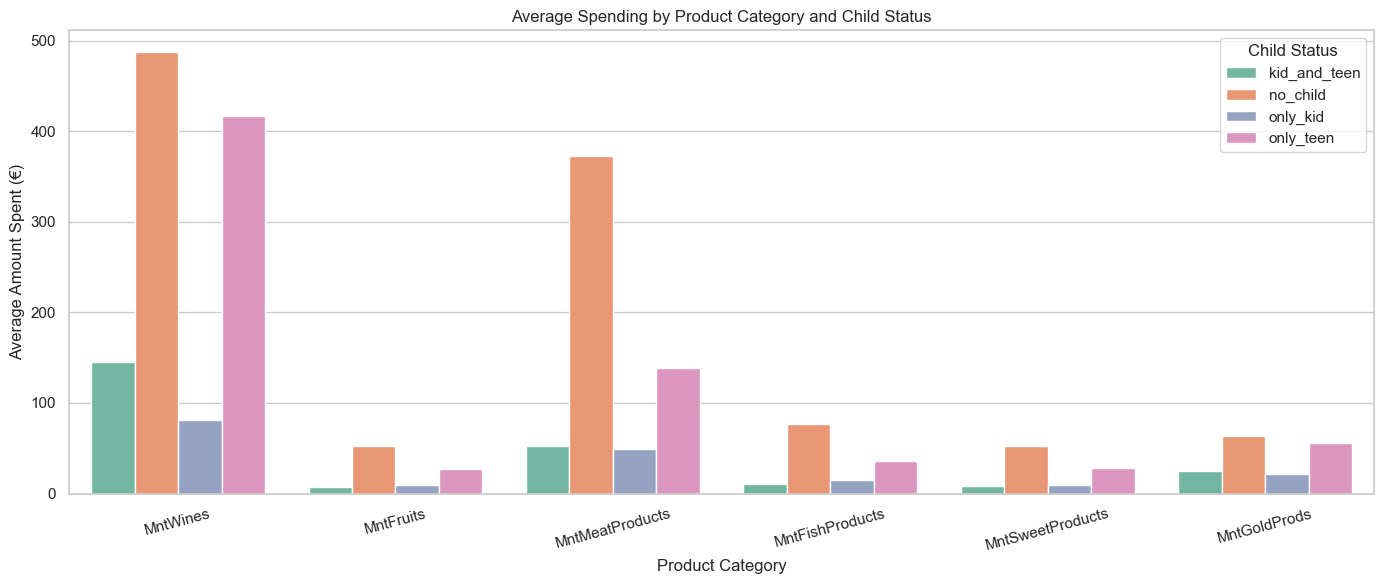

In [74]:
plt.figure(figsize=(14, 6))
sns.barplot(data=child_melted, x='Category', y='Avg_Spent', hue='Child', palette='Set2')
plt.title('Average Spending by Product Category and Child Status')
plt.xlabel('Product Category')
plt.ylabel('Average Amount Spent (€)')
plt.xticks(rotation=15)
plt.legend(title='Child Status', loc='upper right')
plt.tight_layout()
plt.savefig("charts/average_spending_products_by_child.png", dpi= 300, bbox_inches= "tight")
plt.show()

From the graph you can immediately see that the categories that spend the most on average are chstomers without children, followed by customers with teenagers at home. Especially when it comes to spending on wine and meat. <br>
Fruit and sweets are low for all categories.

In [75]:
#Average spending by product types by class of buyers based on the type of children
child_channel = marketing_data.groupby('Child')[['NumWebPurchases',
                                                  'NumCatalogPurchases',
                                                  'NumStorePurchases',
                                                  'NumDealsPurchases']].mean().round(2)
child_channel

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases
Child,,,,
kid_and_teen,3.19,1.10,4.27,3.58
no_child,4.39,4.76,7.27,1.14
only_kid,2.75,0.82,3.65,2.14
only_teen,5.53,3.19,7.17,2.73


In [76]:
# Tansform the child_channel in long format for sns
channel_melted = child_channel.reset_index().melt(
    id_vars='Child', 
    var_name='Channel', 
    value_name='Avg_Spent')

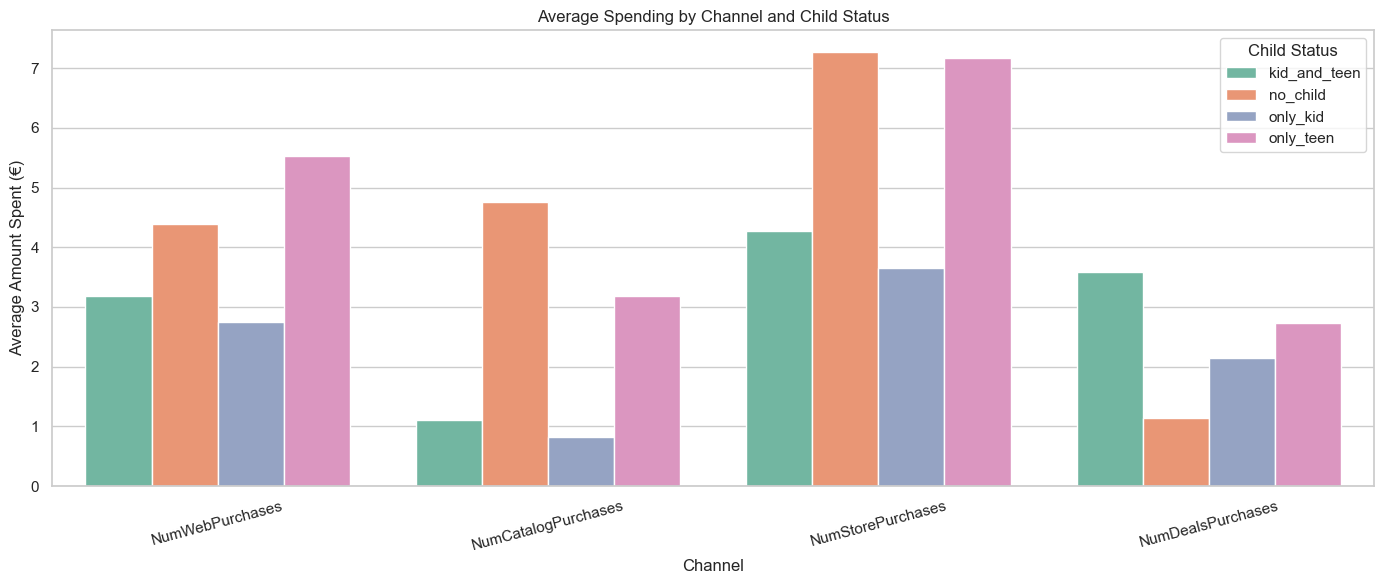

In [77]:
plt.figure(figsize=(14, 6))
sns.barplot(data=channel_melted, x='Channel', y='Avg_Spent', hue='Child', palette='Set2')
plt.title('Average Spending by Channel and Child Status')
plt.xlabel('Channel')
plt.ylabel('Average Amount Spent (€)')
plt.xticks(rotation=15)
plt.legend(title='Child Status', loc='upper right')
plt.tight_layout()
plt.savefig("charts/average_spending_channel_by_child.png", dpi= 300, bbox_inches= "tight")
plt.show()

The store is the dominant channel across all segments, with customers without children and those with teenagers leading in both store and catalog purchases. <br>
Customers with teenagers show the highest web activity, suggesting a preference for online shopping, perhaps pushed by the teenagers themselves
<br> 
In contrast, customers with young children rely more heavily on deals and discounts, indicating higher price sensitivity.

# ANALYSIS 2: Does age affect purchasing behavior?


In [78]:
# Create age groups
bins = [0, 35, 50, 65, 100]
labels = ['Young (18-35)', 'Middle (36-50)', 'Senior (51-65)', 'Elder (65+)']
marketing_data['Age_Group'] = pd.cut(marketing_data['Age'], bins=bins, labels=labels)

marketing_data['Age_Group'].value_counts().sort_index()

Age_Group
Young (18-35)      43
Middle (36-50)    652
Senior (51-65)    926
Elder (65+)       616
Name: count, dtype: int64

In [79]:
#The young group is not very representative, so I group it in the middle group
bins = [0, 50, 65, 100]
labels = ['Young (18-50)', 'Senior (51-65)', 'Elder (65+)']
marketing_data['Age_Group'] = pd.cut(marketing_data['Age'], bins=bins, labels=labels)

marketing_data['Age_Group'].value_counts().sort_index()

Age_Group
Young (18-50)     695
Senior (51-65)    926
Elder (65+)       616
Name: count, dtype: int64

In [80]:
#grouping age categories for different type of purchases
age_spending = marketing_data.groupby('Age_Group', observed=True)[['MntWines','MntFruits',
                                                'MntMeatProducts','MntFishProducts',
                                                'MntSweetProducts','MntGoldProds']].mean().round(2)
print(age_spending)

                MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
Age_Group                                                               
Young (18-50)     240.29      26.42           169.01            36.71   
Senior (51-65)    305.63      24.88           150.08            34.22   
Elder (65+)       373.42      28.19           189.86            43.40   

                MntSweetProducts  MntGoldProds  
Age_Group                                       
Young (18-50)              26.64         41.92  
Senior (51-65)             25.55         42.25  
Elder (65+)                29.84         48.86  


In [81]:
# Tansform the age_spending in long format for sns
age_spending_melted = age_spending.reset_index().melt(
    id_vars='Age_Group', 
    var_name='Category', 
    value_name='Avg_Spent')

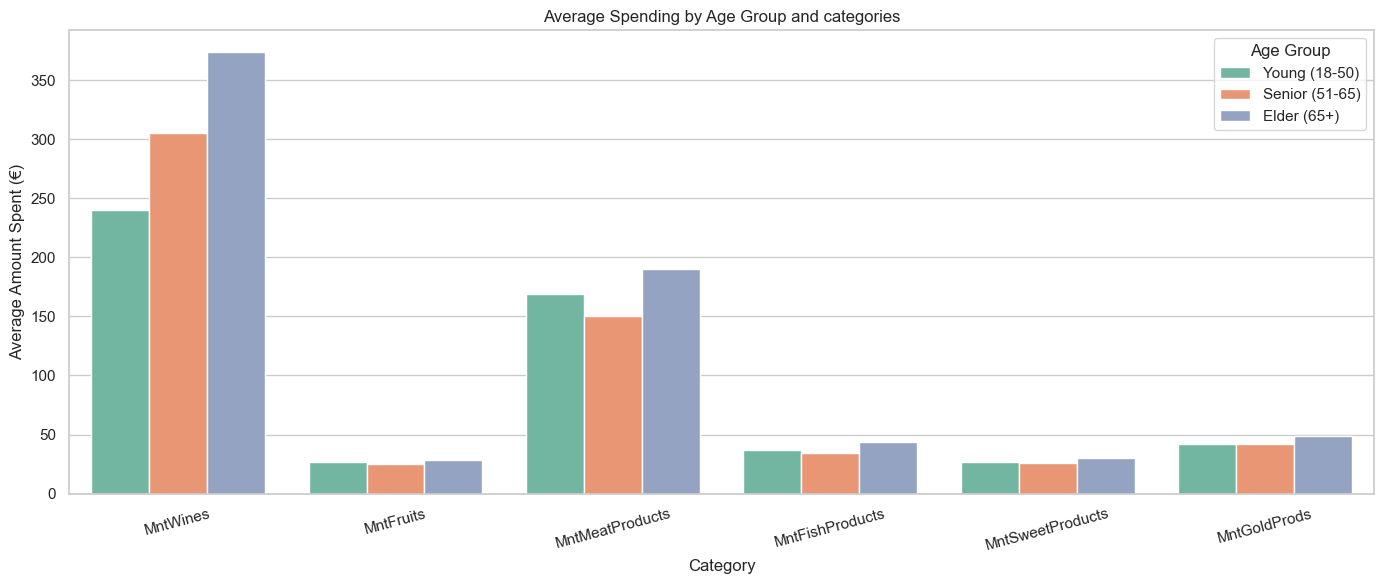

In [82]:
plt.figure(figsize=(14, 6))
sns.barplot(data=age_spending_melted, x='Category', y='Avg_Spent', hue='Age_Group', palette='Set2')
plt.title('Average Spending by Age Group and categories')
plt.xlabel('Category')
plt.ylabel('Average Amount Spent (€)')
plt.xticks(rotation=15)
plt.legend(title='Age Group', loc='upper right')
plt.tight_layout()
plt.savefig("charts/average_spending_category_by_Age.png", dpi= 300, bbox_inches= "tight")
plt.show()

Wine spending increases steadily with age, with Elder customers spending significantly more than younger groups. <br>
Meat follows a similar trend, though Young customers show  surprisingly high spending, suggesting it is a staple across all age groups. <br>
Fruit, fish, sweets and gold remain relatively flat across all age groups, indicating that age is not a significant driver for these categories.

In [83]:
#grouping age categories for different type of purchases
age_channel = marketing_data.groupby('Age_Group', observed=True)[['NumWebPurchases',
                                                  'NumCatalogPurchases',
                                                  'NumStorePurchases',
                                                  'NumDealsPurchases']].mean().round(2)
age_channel

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases
Age_Group,,,,
Young (18-50),3.59,2.33,5.33,2.00
Senior (51-65),4.16,2.49,5.72,2.56
Elder (65+),4.54,3.29,6.43,2.34


In [84]:
# Tansform the age_channel in long format for sns
age_channel_melted = age_channel.reset_index().melt(
    id_vars='Age_Group', 
    var_name='Channel', 
    value_name='Avg_Spent')

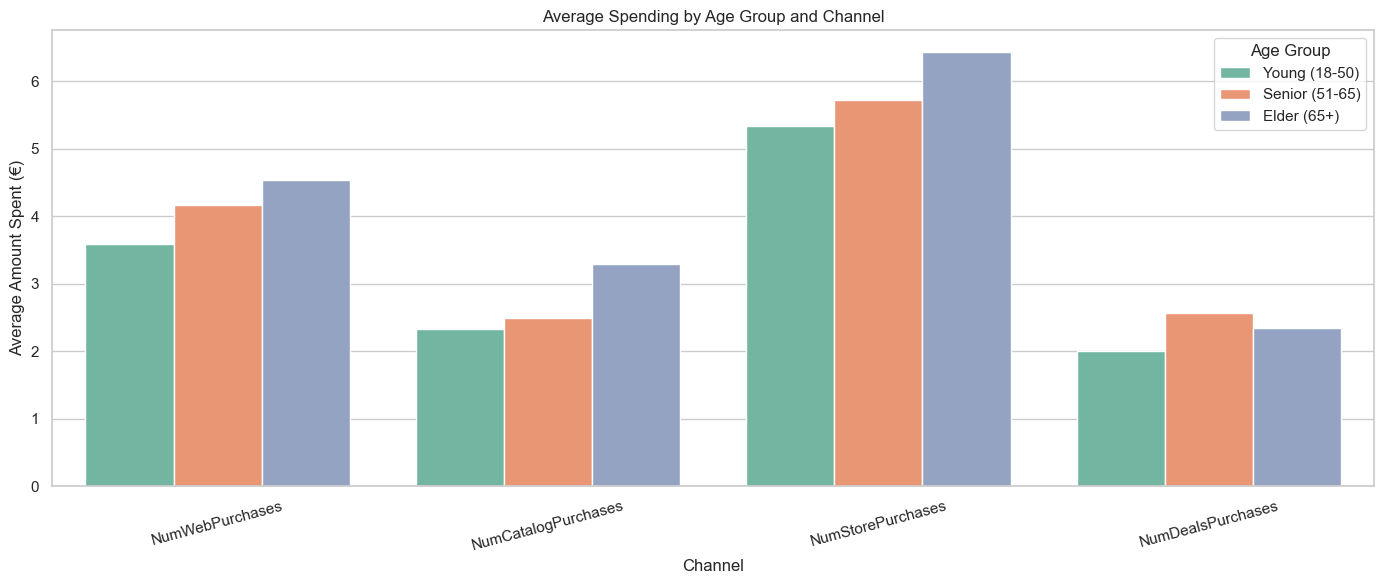

In [85]:
plt.figure(figsize=(14, 6))
sns.barplot(data=age_channel_melted, x='Channel', y='Avg_Spent', hue='Age_Group', palette='Set2')
plt.title('Average Spending by Age Group and Channel')
plt.xlabel('Channel')
plt.ylabel('Average Amount Spent (€)')
plt.xticks(rotation=15)
plt.legend(title='Age Group', loc='upper right')
plt.tight_layout()
plt.savefig("charts/average_spending_channel_by_Age.png", dpi= 300, bbox_inches= "tight")
plt.show()

The spending in all channel increase constantly with age, with a significant preference for store sales for all ages. <br>
Only discount sales peak among the senior and decrease a little among the elder, both still remaining higher than young

# ANALYSIS 3: Young families vs Older families


In [86]:
# Combine Age_Group and Child Status
family_spending = marketing_data.groupby(['Age_Group', 'Child'], observed=True)['total_spent'].mean().round(2)
print(family_spending)

Age_Group       Child       
Young (18-50)   kid_and_teen     235.36
                no_child        1079.44
                only_kid         174.68
                only_teen        756.71
Senior (51-65)  kid_and_teen     250.39
                no_child        1160.48
                only_kid         208.47
                only_teen        721.21
Elder (65+)     kid_and_teen     253.17
                no_child        1083.06
                only_teen        667.23
Name: total_spent, dtype: float64


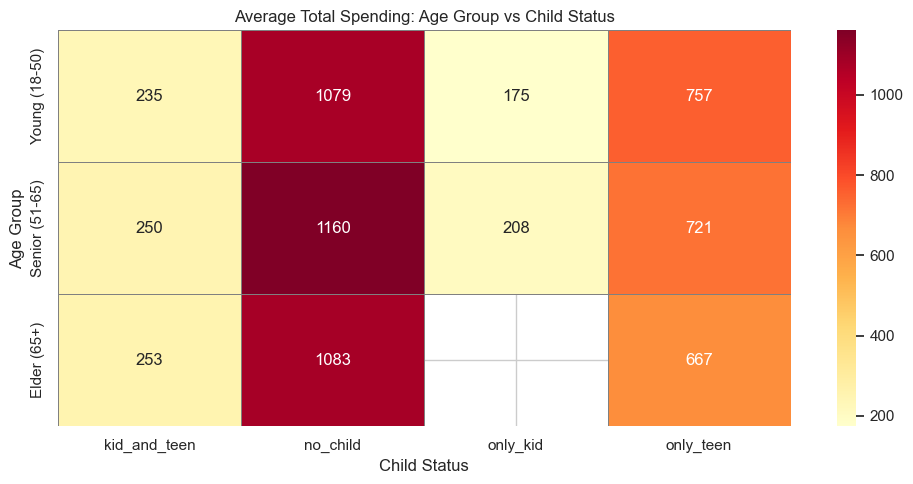

In [87]:
pivot = family_spending.unstack()

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='grey')
plt.title('Average Total Spending: Age Group vs Child Status')
plt.xlabel('Child Status')
plt.ylabel('Age Group')
plt.savefig("charts/average_total_spending_heatmap.png", dpi= 300, bbox_inches= "tight")
plt.tight_layout()
plt.show()

The heatmap clearly confirms that child status is a stronger driver of spending than age. <br> 
Customers without children consistently show the highest average spending  across all age groups (around €1,080 - €1,160), regardless of their age.<br>
Customers with young children spend the least in every age group, rarely exceeding €210. <br>
Notably, Elder customers show no "only_kid" segment, which is expected given their age. <br>
The only_teen segment remains stable across age groups, suggesting that having teenagers does not significantly change with the customer's age.

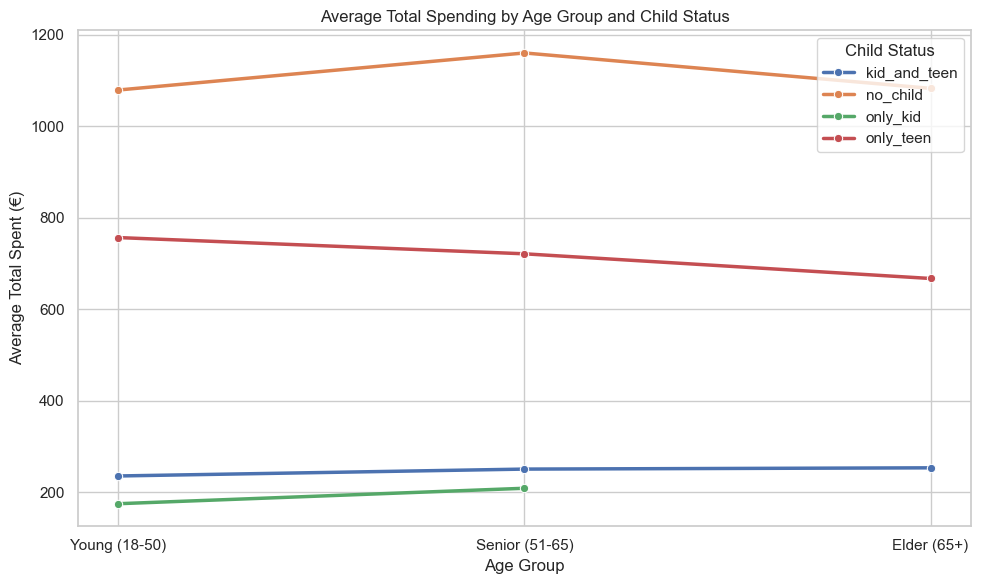

In [88]:
family_line = family_spending.reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=family_line, x='Age_Group', y='total_spent', 
             hue='Child', marker='o', linewidth=2.5)
plt.title('Average Total Spending by Age Group and Child Status')
plt.xlabel('Age Group')
plt.ylabel('Average Total Spent (€)')
plt.legend(title='Child Status')
plt.savefig("charts/average_total_spending_line.png", dpi= 300, bbox_inches= "tight")
plt.tight_layout()
plt.show()


The line plot reveals that child status creates distinct and stable spending tiers across all age groups. <br>
Customers without children peak in the Senior group (€1,160) before slightly declining. The only_teen segment shows a steady decrease with age, 
suggesting older parents of teenagers gradually reduce their spending. <br>
Interestingly, kid_and_teen is the only segment that slightly increases with age, possibly reflecting later-in-life families with higher financial stability.  <br>
Overall, child status is a more consistent predictor of spending than age alone.

# ANALYSIS 4: Campaign analysis

In [89]:
#Create a pie graph to see what campaign is more profitable and how much impact in the total
campaign_dist = marketing_data['Accepted_campaign'].value_counts().sort_index()
campaign_dist

Accepted_campaign
1st_campaign      144
2nd_campaign       17
3rd_campaign      135
4th_campaign      108
5th_campaign       58
last_campaign     146
no campaign      1629
Name: count, dtype: int64

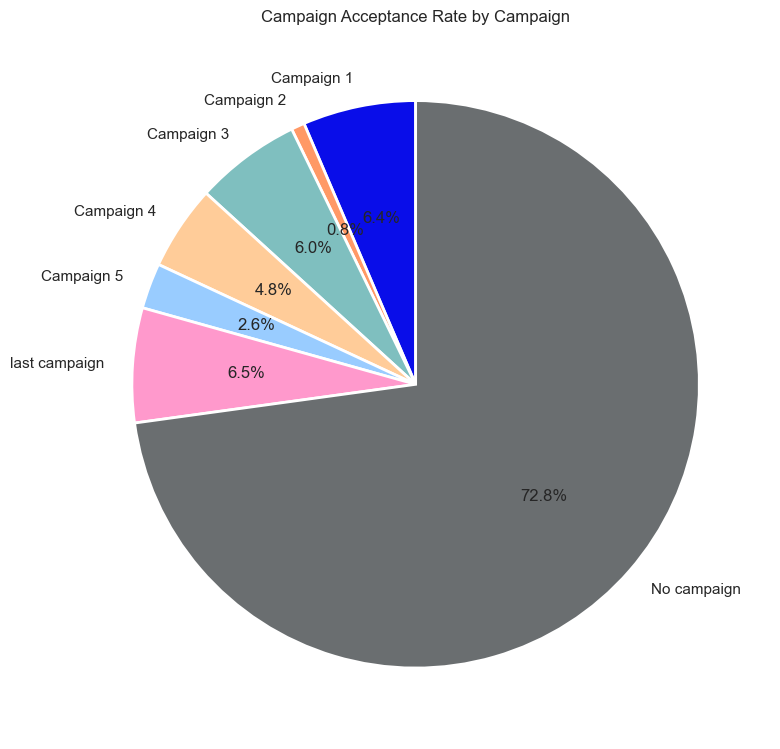

In [90]:
labels = ["Campaign 1", "Campaign 2", "Campaign 3", "Campaign 4", "Campaign 5", "last campaign", "No campaign"]

plt.figure(figsize=(8, 8))
plt.pie(campaign_dist, labels=labels, autopct='%1.1f%%',
        colors=["#090de9",'#ff9966','#7fbfbf','#ffcc99','#99ccff','#ff99cc',"#6a6e70" ],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Campaign Acceptance Rate by Campaign')
plt.savefig("charts/Campaign_Acceptance.png", dpi= 300, bbox_inches= "tight")
plt.tight_layout()
plt.show()

The pie chart reveals that campaigns don't have much impact on the total. <br>
The campaigns are probably not well structured and do not influence as much as they could. <br>
Interestingly, the majority of customers do not become customers after a campaign. Well-structured campaigns could greatly influence the total sale

# ANALYSIS 5: The customers that make complains spent less than other client?

In [91]:
marketing_data['Complain'].value_counts()

Complain
0    2217
1      20
Name: count, dtype: int64

In [92]:
marketing_data.groupby('Complain')[['total_spent', 'Recency']].mean().round(2)

,total_spent,Recency
Complain,,
0,607.67,49.09
1,392.00,50.75


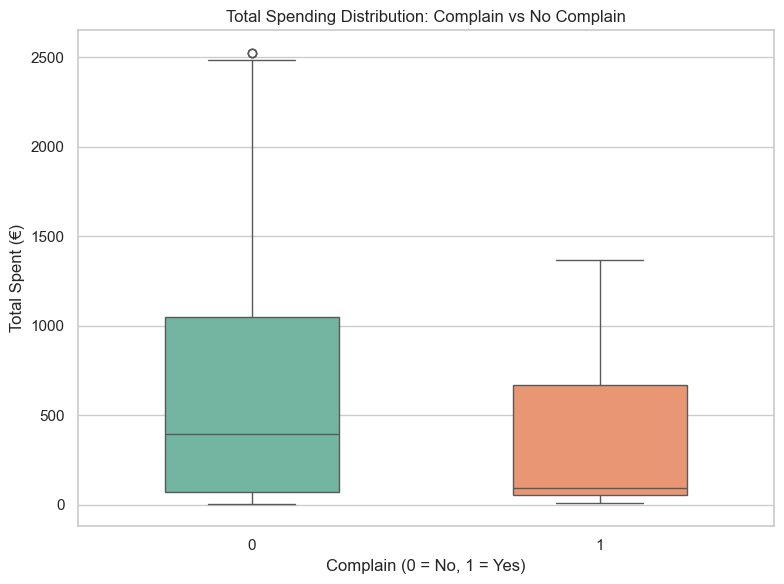

In [94]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=marketing_data, x='Complain', y='total_spent',
            hue='Complain', palette='Set2', width=0.5, legend=False)
plt.title('Total Spending Distribution: Complain vs No Complain')
plt.xlabel('Complain (0 = No, 1 = Yes)')
plt.ylabel('Total Spent (€)')
plt.tight_layout()
plt.savefig("charts/total_spending_complain.png", dpi= 300, bbox_inches= "tight")
plt.show()

The boxplot reveals a clear difference in spending distribution between customers who complained and those who did not. <br>
Customers without complaints (0) show a wider spending range, with a median around €400 and values reaching up to €2,500, including one outlier above €2,500, suggesting a segment of high-value customers. <br>
Customers who complained (1) show a notably compressed distribution, with a lower median around €100 and a maximum of approximately €1,350, indicating that dissatisfied customers are concentrated in lower spending brackets.